In [63]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_circles
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [64]:
np.random.seed(42)
X, y = make_circles(n_samples=500, factor=0.1, noise=0.35, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
     
X.shape

(500, 2)

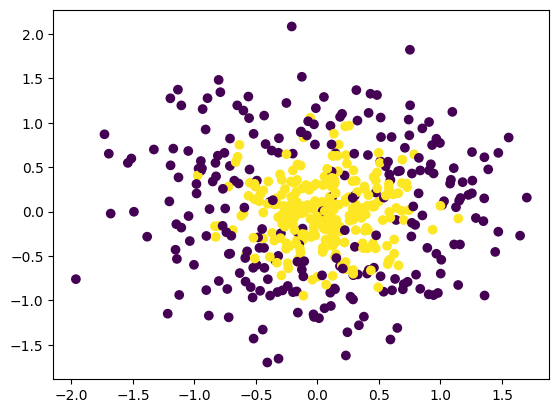

In [65]:
plt.scatter(X[:,0],X[:,1],c=y)

DT vs RF

i. Classification

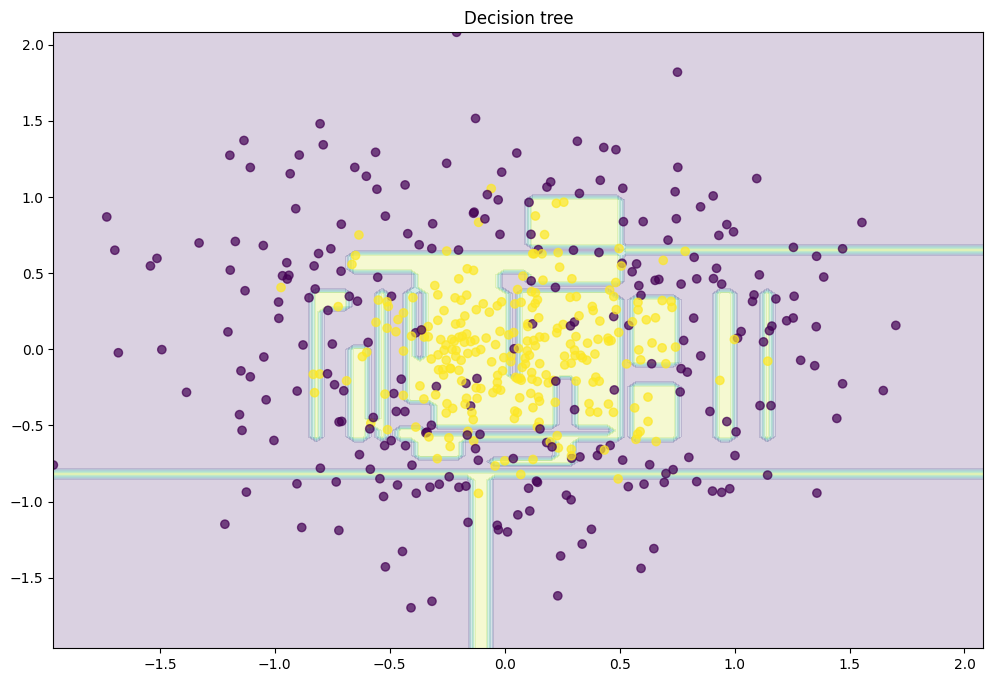

In [66]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = clf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Decision tree")
plt.show()
     


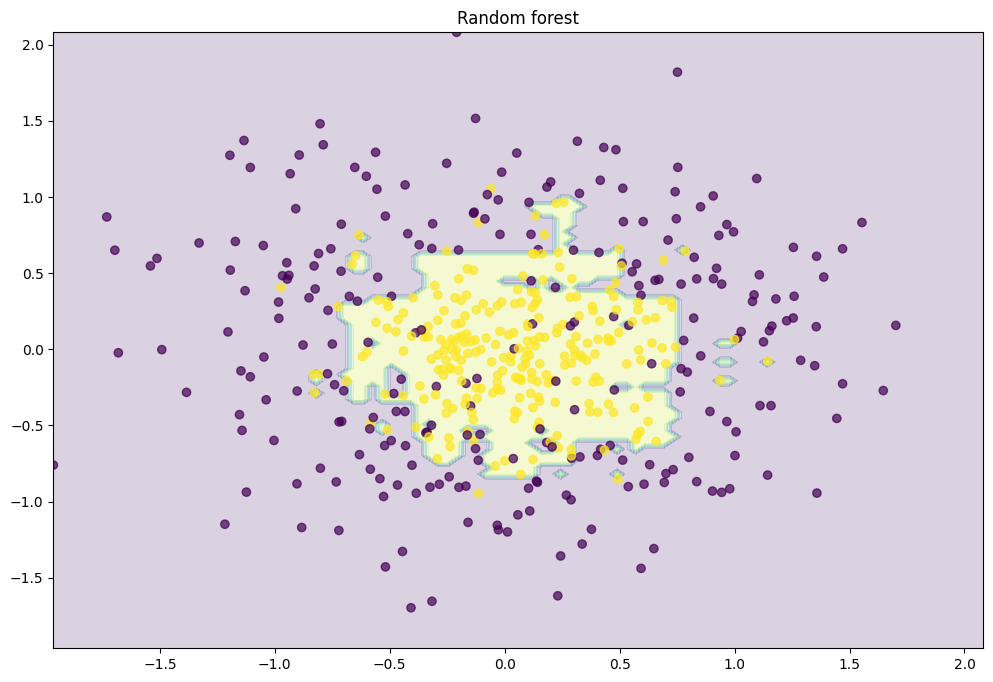

In [67]:

from sklearn.ensemble import RandomForestClassifier
     

rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
x_range = np.linspace(X.min(), X.max(), 100)
xx1, xx2 = np.meshgrid(x_range, x_range)
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=.7)
plt.title("Random forest")
plt.show()

ii. Regression

(-5.0, 5.0)

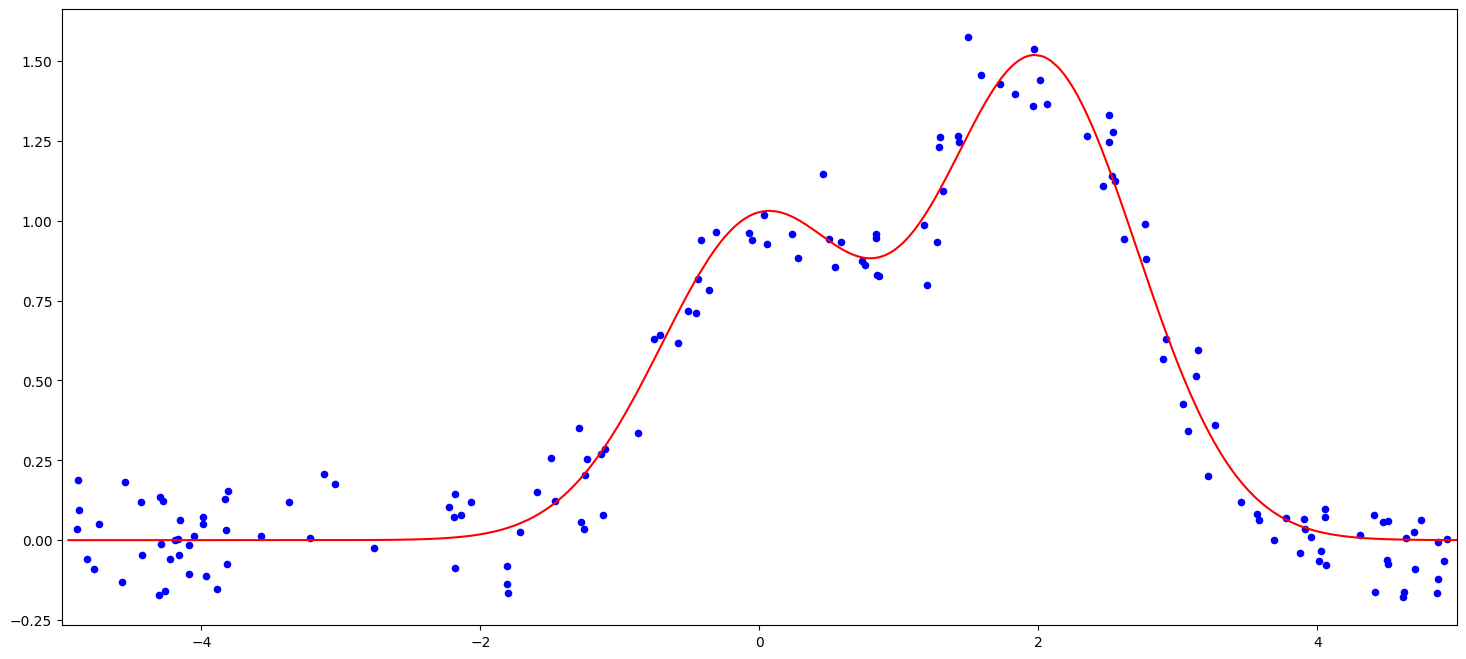

In [68]:
n_train = 150        
n_test = 1000       
noise = 0.1

# Generate data
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

def generate(n_samples, noise):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X).ravel()
    y = np.exp(-X ** 2) + 1.5 * np.exp(-(X - 2) ** 2)\
        + np.random.normal(0.0, noise, n_samples)
    X = X.reshape((n_samples, 1))

    return X, y

X_train, y_train = generate(n_samples=n_train, noise=noise)
X_test, y_test = generate(n_samples=n_test, noise=noise)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.xlim([-5, 5])

Text(0.5, 1.0, 'Decision tree, MSE = 19.27')

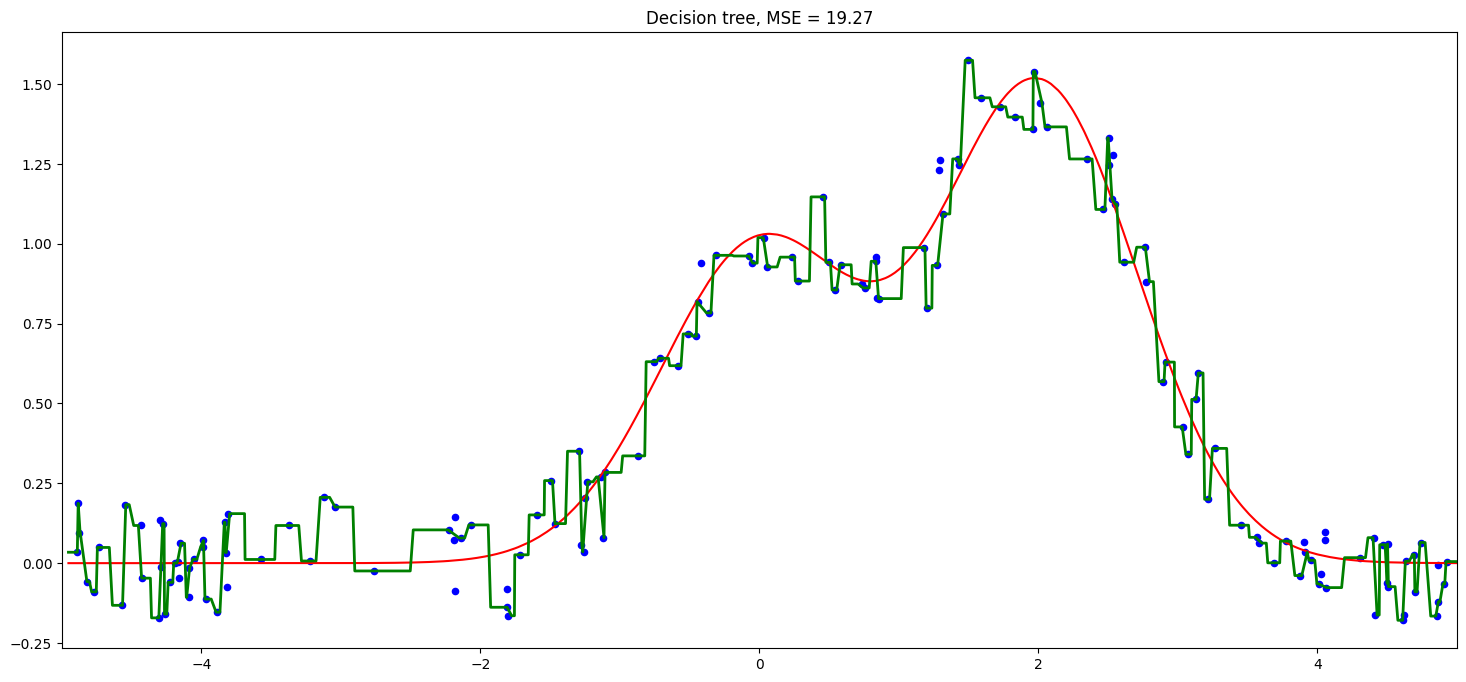

In [69]:
# One decision tree regressor
from sklearn.tree import DecisionTreeRegressor

dtree = DecisionTreeRegressor().fit(X_train, y_train)
d_predict = dtree.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, d_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Decision tree, MSE = %.2f" 
          % np.sum((y_test - d_predict) ** 2))

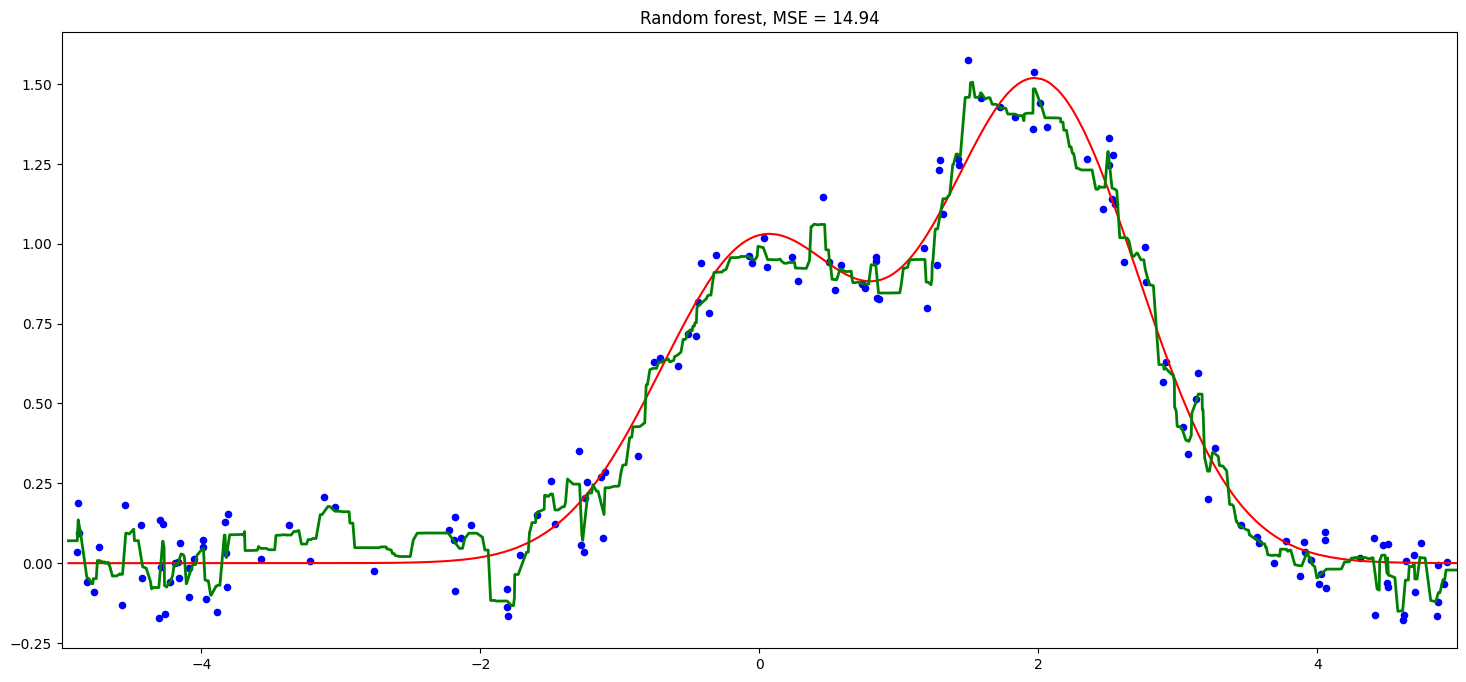

In [70]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rfr = RandomForestRegressor(n_estimators=1000).fit(X_train, y_train)
rf_predict = rfr.predict(X_test)

plt.figure(figsize=(18, 8))
plt.plot(X_test, f(X_test), "r")
plt.scatter(X_train, y_train, c="b", s=20)
plt.plot(X_test, rf_predict, "g", lw=2)
plt.xlim([-5, 5])
plt.title("Random forest, MSE = %.2f" % np.sum((y_test - rf_predict) ** 2));

Comparision between Random forest, Gradient boosting and Logistic regression.

In [71]:
df = pd.read_csv('Datasets/heart_disease_uci.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [72]:
df.shape

(303, 14)

In [73]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((242, 13), (242,), (61, 13), (61,))

In [74]:
lr = LogisticRegression(max_iter=1000)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
svc = SVC()
rf = RandomForestClassifier(n_estimators=100, random_state=42)

for model in [lr, gb, svc, rf]:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{model.__class__.__name__} Accuracy: {accuracy_score(y_test, y_pred):.2f}")

/home/hardik/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 0.87
GradientBoostingClassifier Accuracy: 0.77
SVC Accuracy: 0.70
RandomForestClassifier Accuracy: 0.84


In [75]:
from sklearn.model_selection import cross_val_score
cross_val_score(rf, X, y, cv=5).mean()

np.float64(0.8381967213114756)

GridsearchCV

In [76]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# 108 diff random forest train
param_grid = [
    {
        'bootstrap': [True],
        'max_samples': max_samples,
        'n_estimators': n_estimators,
        'max_features': max_features,
        'max_depth': max_depth
    },
    {
        'bootstrap': [False],
        'max_samples': [None],
        'max_features': max_features,
        'n_estimators': n_estimators,
        'max_depth': max_depth
    }
]
print(param_grid)

[{'bootstrap': [True], 'max_samples': [0.5, 0.75, 1.0], 'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None]}, {'bootstrap': [False], 'max_samples': [None], 'max_features': [0.2, 0.6, 1.0], 'n_estimators': [20, 60, 100, 120], 'max_depth': [2, 8, None]}]


In [77]:
rf_grid = GridSearchCV(estimator=rf,
                       param_grid = param_grid,
                       cv=5,
                       n_jobs=-1,
                       verbose=True)
rf_grid.fit(X_train, y_train)
rf_grid.best_params_,rf_grid.best_score_

Fitting 5 folds for each of 144 candidates, totalling 720 fits


({'bootstrap': True,
  'max_depth': 8,
  'max_features': 0.2,
  'max_samples': 0.75,
  'n_estimators': 20},
 np.float64(0.8386904761904763))

RandomSearchCV

In [78]:
# Number of trees in random forest
n_estimators = [20,60,100,120]

# Number of features to consider at every split
max_features = [0.2,0.6,1.0]

# Maximum number of levels in tree
max_depth = [2,8,None]

# Number of samples
max_samples = [0.5,0.75,1.0]

# Bootstrap samples
bootstrap = [True,False]

# Minimum number of samples required to split a node
min_samples_split = [2, 5]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2]
param_grid = [
    {
        'bootstrap': [True],
        'n_estimators': n_estimators,
        'max_features': max_features,
        'max_depth': max_depth,
        'max_samples': max_samples,
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
        },
    {
        'bootstrap': [False],
        'n_estimators': n_estimators,
        'max_features': max_features,
        'max_depth': max_depth,
        'max_samples': [None],
        'min_samples_split': min_samples_split,
        'min_samples_leaf': min_samples_leaf
    }
]
print(param_grid)

[{'bootstrap': [True], 'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [0.5, 0.75, 1.0], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}, {'bootstrap': [False], 'n_estimators': [20, 60, 100, 120], 'max_features': [0.2, 0.6, 1.0], 'max_depth': [2, 8, None], 'max_samples': [None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}]


In [79]:
from sklearn.model_selection import RandomizedSearchCV

rf_grid = RandomizedSearchCV(estimator = rf, 
                       param_distributions = param_grid, 
                       cv = 5, 
                       verbose=2, 
                       n_jobs = -1)
rf_grid.fit(X_train,y_train)
print(rf_grid.best_params_,rf_grid.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=60; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=60; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=60; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=60; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=20; total time=   0.1s
[CV] END bootstrap=True, max_depth=None, max_features=0.2, max_samples=1.0, min_samples_leaf=2, min_samples_split=2, n_estimators=60; total time=   0.2s
[CV] END bootstrap=Tr

Bagging vs RandomForest

In [80]:
from sklearn.datasets import make_classification
X,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)
     

df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-0.576723,0.765961,0.877810,-1.339941,0.896974,0
1,-4.220982,0.804093,2.080637,0.909775,-0.948837,0
2,2.313618,0.409844,-4.598607,1.981102,-0.222346,1
3,1.569002,-1.250074,3.048700,-2.405005,1.707001,0
4,-0.295495,-1.390475,3.418620,-1.046769,0.746700,0


In [81]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(max_features = 2)
bag.fit(df.drop('target', axis=1), df['target'])


,estimator,None
,n_estimators,10
,max_samples,1.0
,max_features,2
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


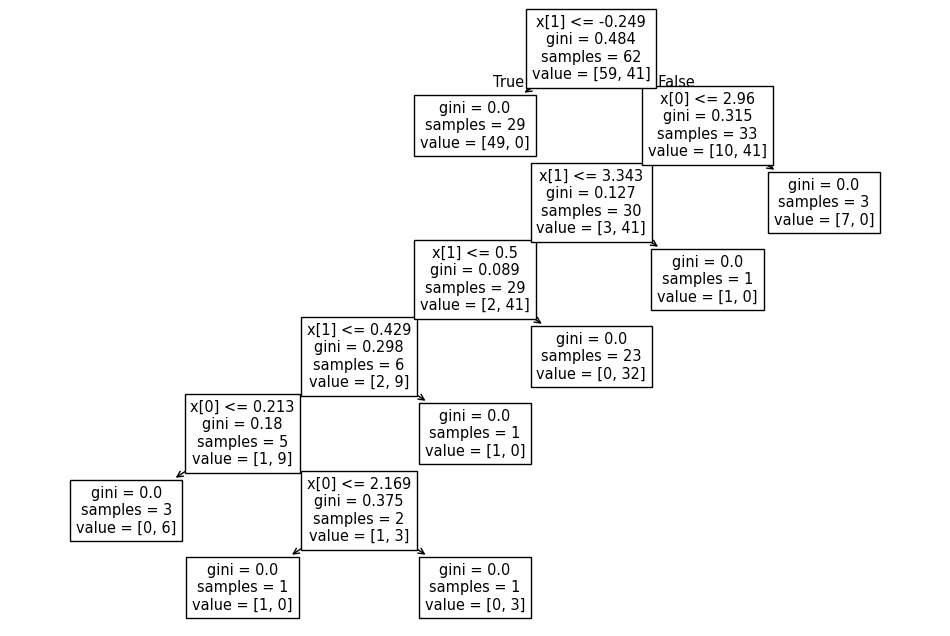

In [82]:
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(bag.estimators_[0])
plt.show()

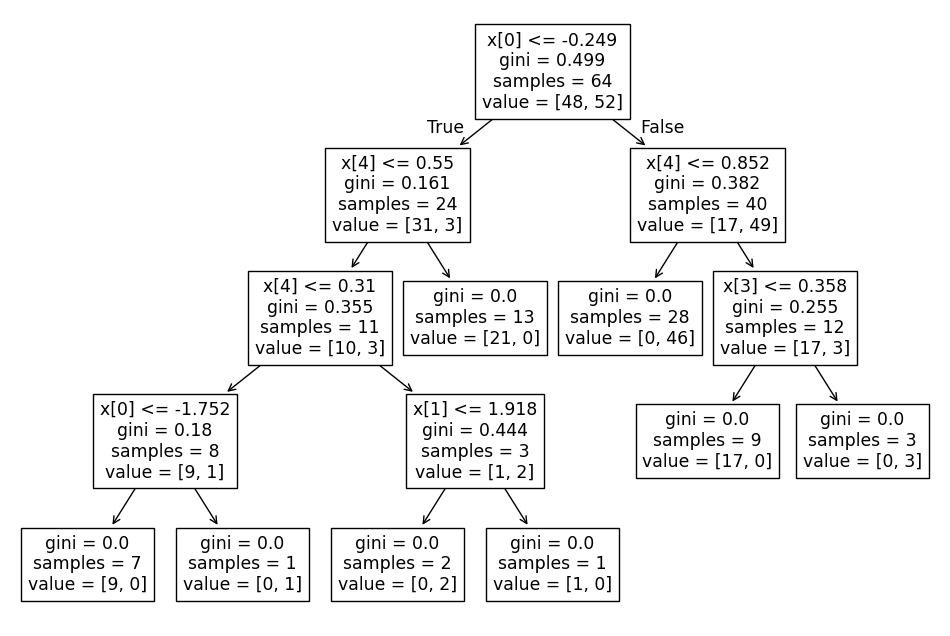

In [84]:
rf = RandomForestClassifier(max_features=2, random_state=42)
rf.fit(df.drop('target', axis=1), df['target'])
plt.figure(figsize=(12, 8))
plot_tree(rf.estimators_[0])
plt.show()